In [1]:
# Dutch BESS Market & Commercial Optimization
# Notebook 2 — BESS Dispatch Optimization
#
# Purpose:
# Build a physically constrained MILP for historical day-ahead arbitrage.
#
# This is a perfect-foresight historical benchmark, not a real-time trading strategy.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import lil_matrix

print("Imports successful.")

Imports successful.


In [3]:
PROJECT_DIR = Path("..").resolve()

DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"

PRICE_FILE = DATA_PROCESSED / "nl_day_ahead_prices_15min_2025-10_to_2026-08.csv"

print("Project directory:", PROJECT_DIR)
print("Price file:", PRICE_FILE)
print("Price file exists:", PRICE_FILE.exists())

Project directory: C:\Users\USER\dutch-bess-market-commercial-optimization
Price file: C:\Users\USER\dutch-bess-market-commercial-optimization\data\processed\nl_day_ahead_prices_15min_2025-10_to_2026-08.csv
Price file exists: True


In [4]:
# load prices
df = pd.read_csv(PRICE_FILE, parse_dates=["timestamp_utc", "timestamp_local"])

df = df.sort_values("timestamp_utc").reset_index(drop=True)

price_col = "day_ahead_price_eur_mwh"

print("Rows:", len(df))
print("Columns:", list(df.columns))
print("Price range:")
print(df[price_col].min(), "→", df[price_col].max())

Rows: 31942
Columns: ['timestamp_utc', 'day_ahead_price_eur_mwh', 'resolution', 'timestamp_local', 'date', 'hour', 'month', 'month_name', 'day_of_week', 'price_change_eur_mwh', 'absolute_price_change_eur_mwh']
Price range:
-499.62 → 902.47


In [5]:
# Reference BESS configuration

POWER_MW = 50.0
ENERGY_MWH = 100.0

MIN_SOC_MWH = 10.0
MAX_SOC_MWH = 90.0

ROUND_TRIP_EFFICIENCY = 0.90
DIRECTIONAL_EFFICIENCY = np.sqrt(ROUND_TRIP_EFFICIENCY)

AVAILABILITY = 0.97
AVAILABLE_POWER_MW = POWER_MW * AVAILABILITY

DT_HOURS = 0.25

INITIAL_SOC_MWH = 10.0

print("BESS configuration")
print("=" * 40)
print(f"Power rating:             {POWER_MW:.1f} MW")
print(f"Energy capacity:          {ENERGY_MWH:.1f} MWh")
print(f"Minimum SOC:              {MIN_SOC_MWH:.1f} MWh")
print(f"Maximum SOC:              {MAX_SOC_MWH:.1f} MWh")
print(f"Round-trip efficiency:    {ROUND_TRIP_EFFICIENCY:.2%}")
print(f"Directional efficiency:   {DIRECTIONAL_EFFICIENCY:.6f}")
print(f"Availability:             {AVAILABILITY:.2%}")
print(f"Available power:          {AVAILABLE_POWER_MW:.1f} MW")
print(f"Time step:                {DT_HOURS:.2f} h")
print(f"Initial SOC:              {INITIAL_SOC_MWH:.1f} MWh")

BESS configuration
Power rating:             50.0 MW
Energy capacity:          100.0 MWh
Minimum SOC:              10.0 MWh
Maximum SOC:              90.0 MWh
Round-trip efficiency:    90.00%
Directional efficiency:   0.948683
Availability:             97.00%
Available power:          48.5 MW
Time step:                0.25 h
Initial SOC:              10.0 MWh


In [6]:
import pandas as pd

# Make sure timestamps are timezone-aware and consistently in Amsterdam time
df["timestamp_local"] = (
    pd.to_datetime(df["timestamp_local"], utc=True)
      .dt.tz_convert("Europe/Amsterdam")
)

# Create the expected 15-minute timestamp sequence
timestamps = pd.date_range(
    start=df["timestamp_local"].min(),
    end=df["timestamp_local"].max(),
    freq="15min"
)

# Actual timestamps in the dataframe
actual_timestamps = pd.DatetimeIndex(df["timestamp_local"])

# Find expected timestamps that are missing
missing_timestamps = timestamps.difference(actual_timestamps)

# Results
print("Expected 15-minute timestamps:", len(timestamps))
print("Actual timestamps:", len(actual_timestamps))
print("Missing timestamps:", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print("\nFirst missing timestamps:")
    print(missing_timestamps[:20])
else:
    print("\nNo missing 15-minute timestamps.")

Expected 15-minute timestamps: 32256
Actual timestamps: 31942
Missing timestamps: 314

First missing timestamps:
DatetimeIndex(['2025-10-02 03:30:00+02:00', '2025-10-04 04:30:00+02:00',
               '2025-10-04 04:45:00+02:00', '2025-10-05 02:45:00+02:00',
               '2025-10-05 05:15:00+02:00', '2025-10-05 05:45:00+02:00',
               '2025-10-05 11:15:00+02:00', '2025-10-11 07:45:00+02:00',
               '2025-10-23 18:15:00+02:00', '2025-10-23 19:45:00+02:00',
               '2025-10-24 03:30:00+02:00', '2025-10-24 03:45:00+02:00',
               '2025-10-25 03:15:00+02:00', '2025-10-25 09:30:00+02:00',
               '2025-10-26 05:30:00+01:00', '2025-10-26 05:45:00+01:00',
               '2025-10-26 12:45:00+01:00', '2025-10-27 03:45:00+01:00',
               '2025-10-27 23:45:00+01:00', '2025-10-28 18:15:00+01:00'],
              dtype='datetime64[ns, Europe/Amsterdam]', freq=None)


In [7]:
# create optimizer price series
price_series = (
    df.set_index("timestamp_local")[price_col]
      .sort_index()
      .reindex(timestamps)
)

price_interpolated_flag = price_series.isna()

price_series = price_series.interpolate(method="time")

print("Price observations:", len(price_series))
print("Interpolated observations:", price_interpolated_flag.sum())
print("Remaining missing prices:", price_series.isna().sum())

optimizer_df = pd.DataFrame({
    "timestamp_local": timestamps,
    "price_eur_mwh": price_series.values,
    "price_interpolated": price_interpolated_flag.values
})

display(optimizer_df.head())

Price observations: 32256
Interpolated observations: 314
Remaining missing prices: 0


,timestamp_local,price_eur_mwh,price_interpolated
0,2025-10-01 00:00:00+02:00,102.55,False
1,2025-10-01 00:15:00+02:00,92.17,False
2,2025-10-01 00:30:00+02:00,82.69,False
3,2025-10-01 00:45:00+02:00,81.86,False
4,2025-10-01 01:00:00+02:00,89.54,False


In [8]:
# ---------------------------------------------------------
# Monthly scenario selection
# ---------------------------------------------------------
#
# We optimize three 30-day historical windows:
#
# 1. Negative-price-heavy month: April 2026
# 2. High-volatility month: June 2026
# 3. Representative month: automatically selected
#
# The representative month is selected using four market
# characteristics:
# - mean price
# - price volatility
# - negative-price frequency
# - average daily price spread
#
# This keeps the optimization manageable while preserving
# different Dutch market regimes.

scenario_months = {
    "negative_price": "2026-04",
    "high_volatility": "2026-06",
}

monthly_metrics = (
    optimizer_df
    .assign(
        month=optimizer_df["timestamp_local"].dt.to_period("M")
    )
    .groupby("month")
    .agg(
        mean_price=("price_eur_mwh", "mean"),
        price_std=("price_eur_mwh", "std"),
        negative_price_share=("price_eur_mwh", lambda x: (x < 0).mean()),
    )
)

# Daily spread by month
daily_spreads = (
    optimizer_df
    .assign(
        month=optimizer_df["timestamp_local"].dt.to_period("M"),
        date=optimizer_df["timestamp_local"].dt.date
    )
    .groupby(["month", "date"])["price_eur_mwh"]
    .agg(["min", "max"])
)

monthly_daily_spread = (
    daily_spreads
    .assign(spread=lambda x: x["max"] - x["min"])
    .groupby("month")["spread"]
    .mean()
    .rename("mean_daily_spread")
)

monthly_metrics = monthly_metrics.join(monthly_daily_spread)

print("Monthly market characteristics:")
display(monthly_metrics.round(2))

Monthly market characteristics:


C:\Users\USER\AppData\Local\Temp\ipykernel_46644\4232192241.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month=optimizer_df["timestamp_local"].dt.to_period("M")
C:\Users\USER\AppData\Local\Temp\ipykernel_46644\4232192241.py:43: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month=optimizer_df["timestamp_local"].dt.to_period("M"),


,mean_price,price_std,negative_price_share,mean_daily_spread
month,,,,
2025-10,82.35,51.52,0.06,146.84
2025-11,93.74,36.96,0.00,101.05
2025-12,87.70,25.69,0.00,71.98
2026-01,107.60,33.02,0.00,85.10
2026-02,92.95,26.75,0.00,81.25
2026-03,98.90,54.55,0.03,185.71
2026-04,84.59,69.66,0.16,218.35
2026-05,94.91,67.90,0.10,201.65
2026-06,110.09,87.49,0.07,256.29


In [9]:
# ---------------------------------------------------------
# Select representative month
# ---------------------------------------------------------

# We compare each month against the overall market profile.
# Standardization prevents one metric from dominating the score.

metrics_for_selection = [
    "mean_price",
    "price_std",
    "negative_price_share",
    "mean_daily_spread",
]

selection_data = monthly_metrics[metrics_for_selection].copy()

overall_profile = selection_data.mean()
overall_std = selection_data.std()

z_scores = (selection_data - overall_profile) / overall_std

# Euclidean distance from the overall market profile
representative_score = np.sqrt((z_scores ** 2).sum(axis=1))

# Exclude the two intentionally selected scenario months
excluded_months = {
    pd.Period(scenario_months["negative_price"], freq="M"),
    pd.Period(scenario_months["high_volatility"], freq="M"),
}

candidate_scores = representative_score.drop(
    labels=[m for m in excluded_months if m in representative_score.index]
)

representative_month = candidate_scores.idxmin()

scenario_months["representative"] = str(representative_month)

print("Selected optimization scenarios:")
print()
print("Negative-price month :", scenario_months["negative_price"])
print("High-volatility month:", scenario_months["high_volatility"])
print("Representative month :", scenario_months["representative"])

print("\nRepresentative-month market characteristics:")
display(
    monthly_metrics.loc[
        representative_month
    ].to_frame("value").round(3)
)

Selected optimization scenarios:

Negative-price month : 2026-04
High-volatility month: 2026-06
Representative month : 2026-03

Representative-month market characteristics:


,value
mean_price,98.903
price_std,54.547
negative_price_share,0.027
mean_daily_spread,185.715


In [10]:
def solve_bess_month(
    optimizer_df,
    month,
    power_mw=POWER_MW,
    energy_mwh=ENERGY_MWH,
    min_soc_mwh=MIN_SOC_MWH,
    max_soc_mwh=MAX_SOC_MWH,
    efficiency=DIRECTIONAL_EFFICIENCY,
    availability=AVAILABILITY,
    dt_hours=DT_HOURS,
    initial_soc_mwh=INITIAL_SOC_MWH,
    max_daily_discharge_cycles=1.0,
):
    """
    Monthly perfect-foresight BESS arbitrage optimization.

    Additional commercial realism constraint:
    total discharged energy per calendar day cannot exceed
    max_daily_discharge_cycles * battery energy capacity.

    Example:
        100 MWh battery × 1 cycle/day = 100 MWh
        maximum daily discharged energy.
    """

    month_period = pd.Period(month, freq="M")

    month_df = optimizer_df[
        optimizer_df["timestamp_local"].dt.to_period("M") == month_period
    ].copy()

    month_df = month_df.sort_values("timestamp_local").reset_index(drop=True)

    if len(month_df) == 0:
        raise ValueError(f"No data found for month {month}")

    prices = month_df["price_eur_mwh"].to_numpy()

    T = len(month_df)

    available_power_mw = power_mw * availability

    # ---------------------------------------------------------
    # Variable indexing
    # ---------------------------------------------------------

    charge_idx = np.arange(0, T)
    discharge_idx = np.arange(T, 2 * T)
    soc_idx = np.arange(2 * T, 3 * T)
    operating_idx = np.arange(3 * T, 4 * T)

    N = 4 * T

    # ---------------------------------------------------------
    # Objective
    #
    # milp minimizes the objective.
    #
    # Charging = cost
    # Discharging = negative revenue
    # ---------------------------------------------------------

    objective = np.zeros(N)

    objective[charge_idx] = prices * dt_hours
    objective[discharge_idx] = -prices * dt_hours

    # ---------------------------------------------------------
    # Constraint count
    #
    # 3T:
    #   SOC balance
    #   charging state
    #   discharging state
    #
    # + 1:
    #   terminal SOC
    #
    # + number of calendar days:
    #   daily discharge-energy limit
    # ---------------------------------------------------------

    day_key = month_df["timestamp_local"].dt.date
    unique_days = pd.Index(day_key.unique())

    n_days = len(unique_days)

    n_constraints = 3 * T + 1 + n_days

    A = lil_matrix((n_constraints, N))

    lower = np.full(n_constraints, -np.inf)
    upper = np.full(n_constraints, np.inf)

    row = 0

    # ---------------------------------------------------------
    # SOC balance
    # ---------------------------------------------------------

    for t in range(T):

        A[row, soc_idx[t]] = 1.0
        A[row, charge_idx[t]] = -efficiency * dt_hours
        A[row, discharge_idx[t]] = dt_hours / efficiency

        if t == 0:

            lower[row] = initial_soc_mwh
            upper[row] = initial_soc_mwh

        else:

            A[row, soc_idx[t - 1]] = -1.0

            lower[row] = 0.0
            upper[row] = 0.0

        row += 1

    # ---------------------------------------------------------
    # Charging state constraint
    #
    # charge <= available_power × operating
    # ---------------------------------------------------------

    for t in range(T):

        A[row, charge_idx[t]] = 1.0
        A[row, operating_idx[t]] = -available_power_mw

        upper[row] = 0.0

        row += 1

    # ---------------------------------------------------------
    # Discharging state constraint
    #
    # discharge <= available_power × (1 - operating)
    # ---------------------------------------------------------

    for t in range(T):

        A[row, discharge_idx[t]] = 1.0
        A[row, operating_idx[t]] = available_power_mw

        upper[row] = available_power_mw

        row += 1

    # ---------------------------------------------------------
    # Terminal SOC
    # ---------------------------------------------------------

    A[row, soc_idx[-1]] = 1.0

    lower[row] = initial_soc_mwh
    upper[row] = initial_soc_mwh

    row += 1

    # ---------------------------------------------------------
    # NEW:
    # Maximum daily discharge energy
    #
    # Sum(discharge_MW × 0.25h) <= 100 MWh/day
    # for a 100 MWh battery and 1 cycle/day.
    # ---------------------------------------------------------

    daily_discharge_limit_mwh = (
        energy_mwh * max_daily_discharge_cycles
    )

    for current_day in unique_days:

        day_positions = np.where(
            day_key.to_numpy() == current_day
        )[0]

        for t in day_positions:

            A[row, discharge_idx[t]] = dt_hours

        lower[row] = -np.inf
        upper[row] = daily_discharge_limit_mwh

        row += 1

    # ---------------------------------------------------------
    # Variable bounds
    # ---------------------------------------------------------

    variable_lower = np.zeros(N)

    variable_upper = np.full(N, np.inf)

    # Power limits
    variable_upper[charge_idx] = available_power_mw
    variable_upper[discharge_idx] = available_power_mw

    # SOC limits
    variable_lower[soc_idx] = min_soc_mwh
    variable_upper[soc_idx] = max_soc_mwh

    # Binary operating state
    variable_lower[operating_idx] = 0
    variable_upper[operating_idx] = 1

    bounds = Bounds(
        variable_lower,
        variable_upper
    )

    integrality = np.zeros(N, dtype=int)

    integrality[operating_idx] = 1

    constraint_object = LinearConstraint(
        A.tocsr(),
        lower,
        upper
    )

    # ---------------------------------------------------------
    # Solve
    # ---------------------------------------------------------

    print(f"\nSolving {month_period}...")
    print("-" * 50)

    print("Intervals:", T)
    print("Variables:", N)
    print("Constraints:", n_constraints)
    print("Available power:", available_power_mw, "MW")
    print(
        "Maximum daily discharge:",
        daily_discharge_limit_mwh,
        "MWh"
    )
    print(
        "Maximum daily cycles:",
        max_daily_discharge_cycles
    )

    result = milp(
        c=objective,
        integrality=integrality,
        bounds=bounds,
        constraints=constraint_object,
        options={"disp": False}
    )

    print("Solver status:", result.status)
    print("Solver message:", result.message)

    if not result.success:
        raise RuntimeError(
            f"MILP failed for {month}: {result.message}"
        )

    # ---------------------------------------------------------
    # Extract solution
    # ---------------------------------------------------------

    solution = result.x

    month_df["charge_mw"] = solution[charge_idx]
    month_df["discharge_mw"] = solution[discharge_idx]
    month_df["soc_mwh"] = solution[soc_idx]
    month_df["operating_binary"] = solution[operating_idx]

    month_df["charge_energy_mwh"] = (
        month_df["charge_mw"] * dt_hours
    )

    month_df["discharge_energy_mwh"] = (
        month_df["discharge_mw"] * dt_hours
    )

    month_df["charge_cost_eur"] = (
        month_df["charge_energy_mwh"]
        * month_df["price_eur_mwh"]
    )

    month_df["discharge_revenue_eur"] = (
        month_df["discharge_energy_mwh"]
        * month_df["price_eur_mwh"]
    )

    month_df["net_revenue_eur"] = (
        month_df["discharge_revenue_eur"]
        - month_df["charge_cost_eur"]
    )

    # ---------------------------------------------------------
    # Daily validation metric
    # ---------------------------------------------------------

    daily_discharge = (
        month_df
        .groupby(month_df["timestamp_local"].dt.date)
        ["discharge_energy_mwh"]
        .sum()
    )

    summary = {
        "month": str(month_period),
        "intervals": T,
        "total_revenue_eur":
            month_df["net_revenue_eur"].sum(),
        "charging_cost_eur":
            month_df["charge_cost_eur"].sum(),
        "discharge_revenue_eur":
            month_df["discharge_revenue_eur"].sum(),
        "energy_charged_mwh":
            month_df["charge_energy_mwh"].sum(),
        "energy_discharged_mwh":
            month_df["discharge_energy_mwh"].sum(),
        "efc":
            month_df["discharge_energy_mwh"].sum()
            / energy_mwh,
        "max_daily_discharge_mwh":
            daily_discharge.max(),
        "max_soc_mwh":
            month_df["soc_mwh"].max(),
        "min_soc_mwh":
            month_df["soc_mwh"].min(),
    }

    return month_df, summary, result

In [11]:
# ---------------------------------------------------------
# Scenario 1 — Negative-price-heavy month
# ---------------------------------------------------------

april_dispatch, april_summary, april_result = solve_bess_month(
    optimizer_df=optimizer_df,
    month=scenario_months["negative_price"]
)

print("\nApril 2026 summary")
print("=" * 50)

for key, value in april_summary.items():
    print(f"{key}: {value}")

C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period



Solving 2026-04...
--------------------------------------------------
Intervals: 2880
Variables: 11520
Constraints: 8671
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0
Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

April 2026 summary
month: 2026-04
intervals: 2880
total_revenue_eur: 466271.39170349576
charging_cost_eur: 24327.019496323097
discharge_revenue_eur: 490598.4111998189
energy_charged_mwh: 3333.3333333333335
energy_discharged_mwh: 3000.0000000000023
efc: 30.00000000000002
max_daily_discharge_mwh: 100.00000000000202
max_soc_mwh: 90.00000000000087
min_soc_mwh: 9.999999999999256


In [12]:
# ---------------------------------------------------------
# Validate April dispatch
# ---------------------------------------------------------

soc_tolerance = 1e-5
power_tolerance = 1e-5

print("April 2026 validation")
print("=" * 50)

print(
    "Minimum SOC:",
    april_dispatch["soc_mwh"].min(),
    "MWh"
)

print(
    "Maximum SOC:",
    april_dispatch["soc_mwh"].max(),
    "MWh"
)

print(
    "Maximum charge power:",
    april_dispatch["charge_mw"].max(),
    "MW"
)

print(
    "Maximum discharge power:",
    april_dispatch["discharge_mw"].max(),
    "MW"
)

print(
    "Initial SOC:",
    april_dispatch["soc_mwh"].iloc[0],
    "MWh"
)

print(
    "Final SOC:",
    april_dispatch["soc_mwh"].iloc[-1],
    "MWh"
)

print("\nConstraint checks:")

soc_ok = (
    april_dispatch["soc_mwh"].min() >= MIN_SOC_MWH - soc_tolerance
    and
    april_dispatch["soc_mwh"].max() <= MAX_SOC_MWH + soc_tolerance
)

power_ok = (
    april_dispatch["charge_mw"].max() <= AVAILABLE_POWER_MW + power_tolerance
    and
    april_dispatch["discharge_mw"].max() <= AVAILABLE_POWER_MW + power_tolerance
)

terminal_ok = (
    abs(
        april_dispatch["soc_mwh"].iloc[-1]
        - INITIAL_SOC_MWH
    ) <= soc_tolerance
)

simultaneous_ok = (
    (
        april_dispatch["charge_mw"]
        * april_dispatch["discharge_mw"]
    ) <= power_tolerance
).all()

print("SOC limits:", soc_ok)
print("Power limits:", power_ok)
print("Terminal SOC:", terminal_ok)
print("No simultaneous charge/discharge:", simultaneous_ok)

print("\nOverall validation:",
      all([soc_ok, power_ok, terminal_ok, simultaneous_ok]))

April 2026 validation
Minimum SOC: 9.999999999999256 MWh
Maximum SOC: 90.00000000000087 MWh
Maximum charge power: 48.5 MW
Maximum discharge power: 48.5 MW
Initial SOC: 10.0 MWh
Final SOC: 10.0 MWh

Constraint checks:
SOC limits: True
Power limits: True
Terminal SOC: True
No simultaneous charge/discharge: True

Overall validation: True


In [13]:
# ---------------------------------------------------------
# Scenario 2 — High-volatility month
# ---------------------------------------------------------

june_dispatch, june_summary, june_result = solve_bess_month(
    optimizer_df=optimizer_df,
    month=scenario_months["high_volatility"]
)

print("\nJune 2026 summary")
print("=" * 50)

for key, value in june_summary.items():
    print(f"{key}: {value}")


Solving 2026-06...
--------------------------------------------------
Intervals: 2880
Variables: 11520
Constraints: 8671
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0


C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period


Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

June 2026 summary
month: 2026-06
intervals: 2880
total_revenue_eur: 531040.2448683265
charging_cost_eur: 146501.9341984925
discharge_revenue_eur: 677542.179066819
energy_charged_mwh: 3333.3333333333335
energy_discharged_mwh: 3000.0
efc: 30.0
max_daily_discharge_mwh: 100.0
max_soc_mwh: 90.00000000000003
min_soc_mwh: 9.99999999999999


In [14]:
# ---------------------------------------------------------
# Scenario 3 — Representative month
# ---------------------------------------------------------

march_dispatch, march_summary, march_result = solve_bess_month(
    optimizer_df=optimizer_df,
    month=scenario_months["representative"]
)

print("\nRepresentative month summary")
print("=" * 50)

for key, value in march_summary.items():
    print(f"{key}: {value}")

C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period



Solving 2026-03...
--------------------------------------------------
Intervals: 2972
Variables: 11888
Constraints: 8948
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0
Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Representative month summary
month: 2026-03
intervals: 2972
total_revenue_eur: 418588.15176030307
charging_cost_eur: 123275.3722958543
discharge_revenue_eur: 541863.5240561573
energy_charged_mwh: 3444.4444444444443
energy_discharged_mwh: 3100.0
efc: 31.0
max_daily_discharge_mwh: 100.0
max_soc_mwh: 90.0
min_soc_mwh: 10.0


In [15]:
# ---------------------------------------------------------
# Compare optimization scenarios
# ---------------------------------------------------------

scenario_summary = pd.DataFrame([
    april_summary,
    june_summary,
    march_summary
])

scenario_summary = scenario_summary.set_index("month")

display(
    scenario_summary[
        [
            "total_revenue_eur",
            "charging_cost_eur",
            "discharge_revenue_eur",
            "energy_charged_mwh",
            "energy_discharged_mwh",
            "max_soc_mwh",
            "min_soc_mwh",
        ]
    ].round(2)
)

,total_revenue_eur,charging_cost_eur,discharge_revenue_eur,energy_charged_mwh,energy_discharged_mwh,max_soc_mwh,min_soc_mwh
month,,,,,,,
2026-04,466271.39,24327.02,490598.41,3333.33,3000.0,90.0,10.0
2026-06,531040.24,146501.93,677542.18,3333.33,3000.0,90.0,10.0
2026-03,418588.15,123275.37,541863.52,3444.44,3100.0,90.0,10.0


In [16]:
# ---------------------------------------------------------
# Operating metrics for each scenario
# ---------------------------------------------------------

scenario_summary["round_trip_energy_ratio"] = (
    scenario_summary["energy_discharged_mwh"]
    / scenario_summary["energy_charged_mwh"]
)

scenario_summary["equivalent_full_cycles"] = (
    scenario_summary["energy_discharged_mwh"]
    / ENERGY_MWH
)

scenario_summary["revenue_per_mw_month"] = (
    scenario_summary["total_revenue_eur"]
    / POWER_MW
)

scenario_summary["revenue_per_mwh_capacity_month"] = (
    scenario_summary["total_revenue_eur"]
    / ENERGY_MWH
)

display(
    scenario_summary[
        [
            "total_revenue_eur",
            "energy_charged_mwh",
            "energy_discharged_mwh",
            "round_trip_energy_ratio",
            "equivalent_full_cycles",
            "revenue_per_mw_month",
            "revenue_per_mwh_capacity_month",
        ]
    ].round(2)
)

,total_revenue_eur,energy_charged_mwh,energy_discharged_mwh,round_trip_energy_ratio,equivalent_full_cycles,revenue_per_mw_month,revenue_per_mwh_capacity_month
month,,,,,,,
2026-04,466271.39,3333.33,3000.0,0.9,30.0,9325.43,4662.71
2026-06,531040.24,3333.33,3000.0,0.9,30.0,10620.80,5310.40
2026-03,418588.15,3444.44,3100.0,0.9,31.0,8371.76,4185.88


In [17]:
# ---------------------------------------------------------
# Save monthly optimization summary
# ---------------------------------------------------------

OPTIMIZATION_SUMMARY_FILE = (
    RESULTS_DIR / "monthly_bess_arbitrage_scenarios.csv"
)

scenario_summary.to_csv(OPTIMIZATION_SUMMARY_FILE)

print("Saved:")
print(OPTIMIZATION_SUMMARY_FILE)

Saved:
C:\Users\USER\dutch-bess-market-commercial-optimization\results\monthly_bess_arbitrage_scenarios.csv


In [18]:
# Complete calendar months available in the dataset
full_months = [
    "2025-10",
    "2025-11",
    "2025-12",
    "2026-01",
    "2026-02",
    "2026-03",
    "2026-04",
    "2026-05",
    "2026-06",
    "2026-07",
    "2026-08",
]

print("Months to optimize:")
for m in full_months:
    print(" -", m)

print("\nNumber of months:", len(full_months))

Months to optimize:
 - 2025-10
 - 2025-11
 - 2025-12
 - 2026-01
 - 2026-02
 - 2026-03
 - 2026-04
 - 2026-05
 - 2026-06
 - 2026-07
 - 2026-08

Number of months: 11


In [19]:
monthly_dispatch_results = {}
monthly_solver_results = {}
monthly_summaries = []

for month in full_months:
    dispatch, summary, solver_result = solve_bess_month(
        optimizer_df=optimizer_df,
        month=month
    )

    monthly_dispatch_results[month] = dispatch
    monthly_solver_results[month] = solver_result
    monthly_summaries.append(summary)

    print(
        f"{month}: "
        f"Revenue = €{summary['total_revenue_eur']:,.0f} | "
        f"Discharged = {summary['energy_discharged_mwh']:,.0f} MWh"
    )

monthly_summary_df = pd.DataFrame(monthly_summaries).set_index("month")

print("\nAll monthly optimizations completed.")

C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period



Solving 2025-10...
--------------------------------------------------
Intervals: 2980
Variables: 11920
Constraints: 8972
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0
Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
2025-10: Revenue = €308,442 | Discharged = 3,100 MWh

Solving 2025-11...
--------------------------------------------------
Intervals: 2880
Variables: 11520
Constraints: 8671
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0


C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period


Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
2025-11: Revenue = €194,110 | Discharged = 3,000 MWh

Solving 2025-12...
--------------------------------------------------
Intervals: 2976
Variables: 11904
Constraints: 8960
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0


C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period


...

Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
2026-06: Revenue = €531,040 | Discharged = 3,000 MWh

Solving 2026-07...
--------------------------------------------------
Intervals: 2976
Variables: 11904
Constraints: 8960
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0


C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period


Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
2026-07: Revenue = €406,073 | Discharged = 3,100 MWh

Solving 2026-08...
--------------------------------------------------
Intervals: 2976
Variables: 11904
Constraints: 8960
Available power: 48.5 MW
Maximum daily discharge: 100.0 MWh
Maximum daily cycles: 1.0


C:\Users\USER\AppData\Local\Temp\ipykernel_46644\633228706.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  optimizer_df["timestamp_local"].dt.to_period("M") == month_period


Solver status: 0
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
2026-08: Revenue = €434,396 | Discharged = 3,100 MWh

All monthly optimizations completed.


In [20]:
annual_revenue = monthly_summary_df["total_revenue_eur"].sum()
annual_charging_cost = monthly_summary_df["charging_cost_eur"].sum()
annual_discharge_revenue = monthly_summary_df["discharge_revenue_eur"].sum()
annual_energy_charged = monthly_summary_df["energy_charged_mwh"].sum()
annual_energy_discharged = monthly_summary_df["energy_discharged_mwh"].sum()

annual_efc = annual_energy_discharged / ENERGY_MWH

print("Historical Perfect-Foresight Wholesale Arbitrage Benchmark")
print("=" * 60)
print(f"Months optimized:              {len(full_months)}")
print(f"Wholesale arbitrage revenue:   €{annual_revenue:,.0f}")
print(f"Charging cost:                  €{annual_charging_cost:,.0f}")
print(f"Discharge revenue:              €{annual_discharge_revenue:,.0f}")
print(f"Energy charged:                 {annual_energy_charged:,.0f} MWh")
print(f"Energy discharged:              {annual_energy_discharged:,.0f} MWh")
print(f"Equivalent full cycles:         {annual_efc:,.1f}")
print(f"Revenue per MW:                 €{annual_revenue / POWER_MW:,.0f}")
print(f"Revenue per MWh capacity:       €{annual_revenue / ENERGY_MWH:,.0f}")

Historical Perfect-Foresight Wholesale Arbitrage Benchmark
Months optimized:              11
Wholesale arbitrage revenue:   €3,648,376
Charging cost:                  €1,777,456
Discharge revenue:              €5,425,832
Energy charged:                 37,205 MWh
Energy discharged:              33,485 MWh
Equivalent full cycles:         334.8
Revenue per MW:                 €72,968
Revenue per MWh capacity:       €36,484


In [21]:
monthly_summary_df[
    [
        "total_revenue_eur",
        "energy_charged_mwh",
        "energy_discharged_mwh",
        "max_soc_mwh",
        "min_soc_mwh",
    ]
].round(2)

,total_revenue_eur,energy_charged_mwh,energy_discharged_mwh,max_soc_mwh,min_soc_mwh
month,,,,,
2025-10,308441.64,3444.44,3100.00,90.0,10.0
2025-11,194109.58,3333.33,3000.00,90.0,10.0
2025-12,136921.14,3444.44,3100.00,90.0,10.0
2026-01,167294.58,3427.25,3084.53,90.0,10.0
2026-02,142498.32,3111.11,2800.00,90.0,10.0
2026-03,418588.15,3444.44,3100.00,90.0,10.0
2026-04,466271.39,3333.33,3000.00,90.0,10.0
2026-05,442742.22,3444.44,3100.00,90.0,10.0
2026-06,531040.24,3333.33,3000.00,90.0,10.0


In [22]:
# Save the full historical monthly optimization benchmark

FULL_RESULTS_FILE = RESULTS_DIR / "monthly_bess_arbitrage_full_history.csv"

monthly_summary_df.to_csv(FULL_RESULTS_FILE)

print("Saved full historical optimization results:")
print(FULL_RESULTS_FILE)

Saved full historical optimization results:
C:\Users\USER\dutch-bess-market-commercial-optimization\results\monthly_bess_arbitrage_full_history.csv


In [23]:
print("Notebook 2 — Dispatch Optimization Summary")
print("=" * 60)

print(f"Historical period optimized: October 2025 to August 2026")
print(f"Complete months optimized:   {len(full_months)}")
print(f"Battery size:                {POWER_MW} MW / {ENERGY_MWH} MWh")
print(f"Available power:             {AVAILABLE_POWER_MW} MW")
print(f"Usable SOC range:            {MIN_SOC_MWH}–{MAX_SOC_MWH} MWh")
print(f"Round-trip efficiency:       {ROUND_TRIP_EFFICIENCY:.0%}")
print(f"Historical arbitrage revenue: €{annual_revenue:,.0f}")
print(f"Equivalent full cycles:      {annual_efc:,.1f}")

print("\nScenario months:")
print(f"Negative-price month:        {scenario_months['negative_price']}")
print(f"High-volatility month:       {scenario_months['high_volatility']}")
print(f"Representative month:        {scenario_months['representative']}")

print("\nAll monthly MILPs solved successfully.")

Notebook 2 — Dispatch Optimization Summary
Historical period optimized: October 2025 to August 2026
Complete months optimized:   11
Battery size:                50.0 MW / 100.0 MWh
Available power:             48.5 MW
Usable SOC range:            10.0–90.0 MWh
Round-trip efficiency:       90%
Historical arbitrage revenue: €3,648,376
Equivalent full cycles:      334.8

Scenario months:
Negative-price month:        2026-04
High-volatility month:       2026-06
Representative month:        2026-03

All monthly MILPs solved successfully.


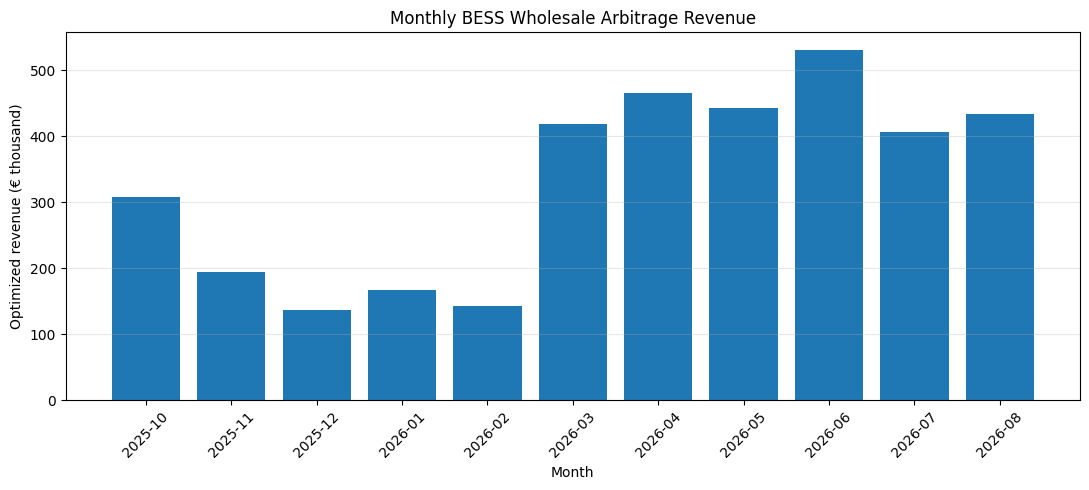

In [24]:
# Final operational figure 1:
# Monthly optimized wholesale arbitrage revenue

plot_df = pd.read_csv(
    RESULTS_DIR / "monthly_bess_arbitrage_full_history.csv"
)

plot_df["month"] = plot_df["month"].astype(str)

plt.figure(figsize=(11, 5))

plt.bar(
    plot_df["month"],
    plot_df["total_revenue_eur"] / 1000
)

plt.xlabel("Month")
plt.ylabel("Optimized revenue (€ thousand)")
plt.title("Monthly BESS Wholesale Arbitrage Revenue")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_wholesale_arbitrage_revenue.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

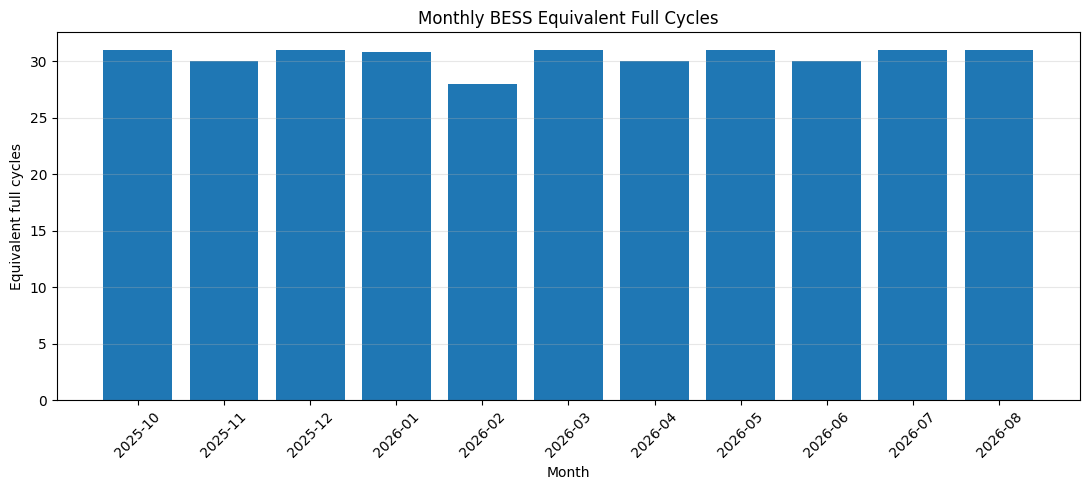

In [25]:
# Final operational figure 2:
# Monthly equivalent full cycles

plot_df = pd.read_csv(
    RESULTS_DIR / "monthly_bess_arbitrage_full_history.csv"
)

plot_df["month"] = plot_df["month"].astype(str)

plt.figure(figsize=(11, 5))

plt.bar(
    plot_df["month"],
    plot_df["efc"]
)

plt.xlabel("Month")
plt.ylabel("Equivalent full cycles")
plt.title("Monthly BESS Equivalent Full Cycles")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "monthly_bess_efc.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [27]:
# Final operational figure 3:
# Example dispatch during the high-volatility June 2026 period

# Load the saved full-history optimization results
full_history_results = pd.read_csv(
    RESULTS_DIR / "monthly_bess_arbitrage_full_history.csv"
)

print("Columns available:")
print(full_history_results.columns.tolist())

Columns available:
['month', 'intervals', 'total_revenue_eur', 'charging_cost_eur', 'discharge_revenue_eur', 'energy_charged_mwh', 'energy_discharged_mwh', 'efc', 'max_daily_discharge_mwh', 'max_soc_mwh', 'min_soc_mwh']


In [28]:
# Inspect variables currently available after the June optimization

print([
    name for name in dir()
    if "june" in name.lower()
    or "month" in name.lower()
    or "result" in name.lower()
])

['FULL_RESULTS_FILE', 'RESULTS_DIR', 'april_result', 'excluded_months', 'full_history_results', 'full_months', 'june_dispatch', 'june_result', 'june_summary', 'march_result', 'month', 'monthly_daily_spread', 'monthly_dispatch_results', 'monthly_metrics', 'monthly_solver_results', 'monthly_summaries', 'monthly_summary_df', 'representative_month', 'scenario_months', 'solve_bess_month', 'solver_result']


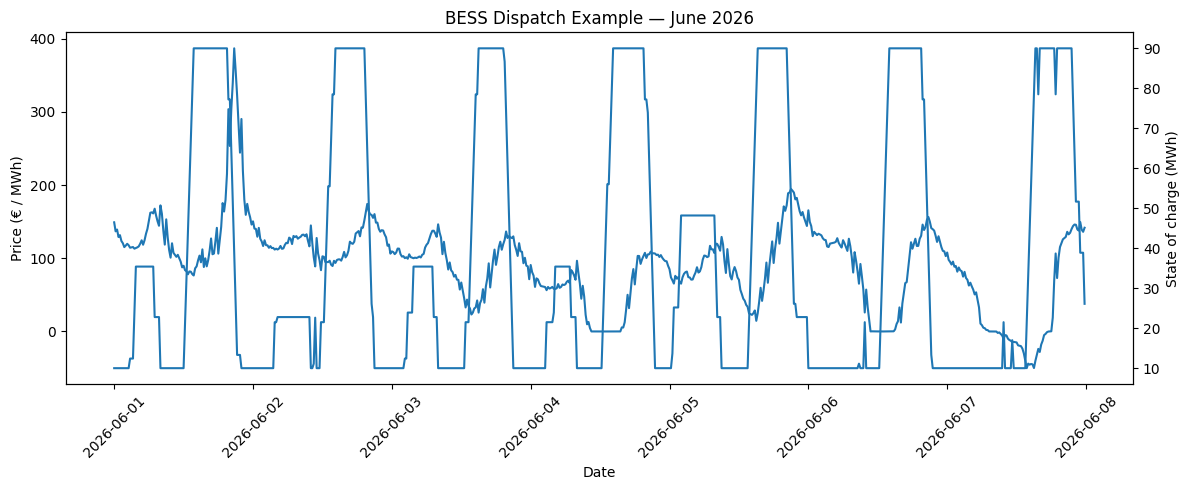

In [29]:
# Final operational figure 3:
# Example dispatch during high-volatility June 2026

june_dispatch["timestamp_local"] = pd.to_datetime(
    june_dispatch["timestamp_local"]
)

june_plot = june_dispatch[
    (june_dispatch["timestamp_local"] >= "2026-06-01") &
    (june_dispatch["timestamp_local"] < "2026-06-08")
].copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    june_plot["timestamp_local"],
    june_plot["price_eur_mwh"],
    label="Day-ahead price (€ / MWh)"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Price (€ / MWh)")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()

ax2.plot(
    june_plot["timestamp_local"],
    june_plot["soc_mwh"],
    label="Battery SOC (MWh)"
)

ax2.set_ylabel("State of charge (MWh)")

plt.title("BESS Dispatch Example — June 2026")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "june_2026_bess_dispatch_example.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()